**hierarchical and UMAP clustering**


Silhouette scores by number of clusters:
  k=2: silhouette = 0.6432
  k=3: silhouette = 0.6092
  k=4: silhouette = 0.5050
  k=5: silhouette = 0.4665
  k=6: silhouette = 0.4538

Using k=2 (silhouette=0.6432)


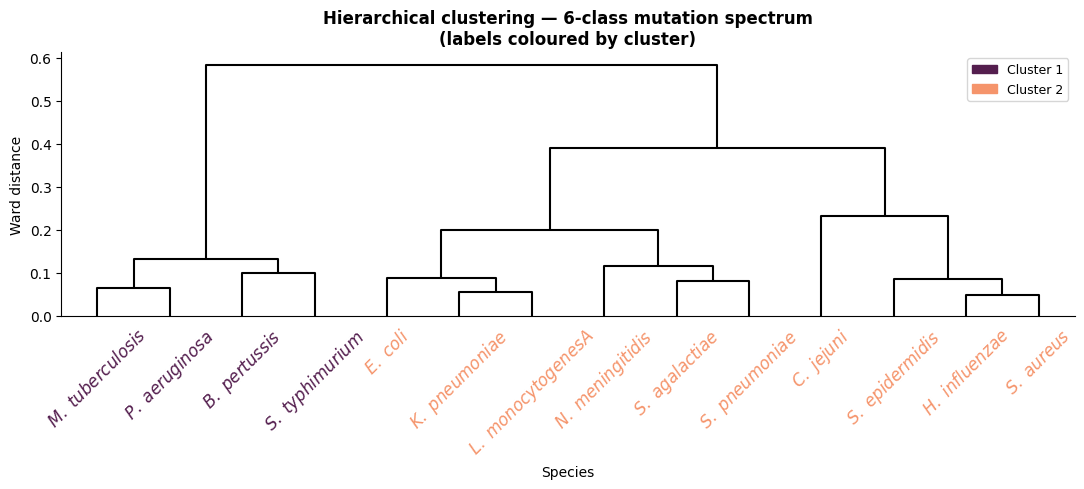

Saved hierarchical_clustering_6class.png

Variance explained per PC:
  PC1: 82.5%  (cumulative: 82.5%)
  PC2: 8.5%  (cumulative: 91.0%)
  PC3: 5.9%  (cumulative: 96.9%)


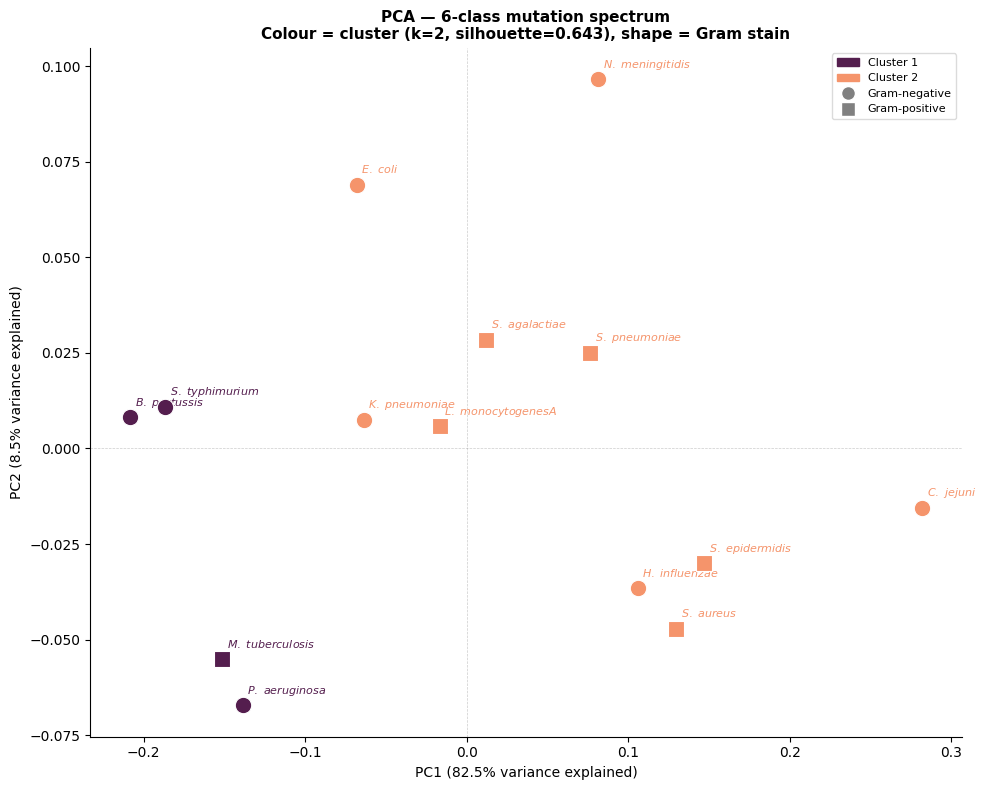

Saved pca_scatter.png


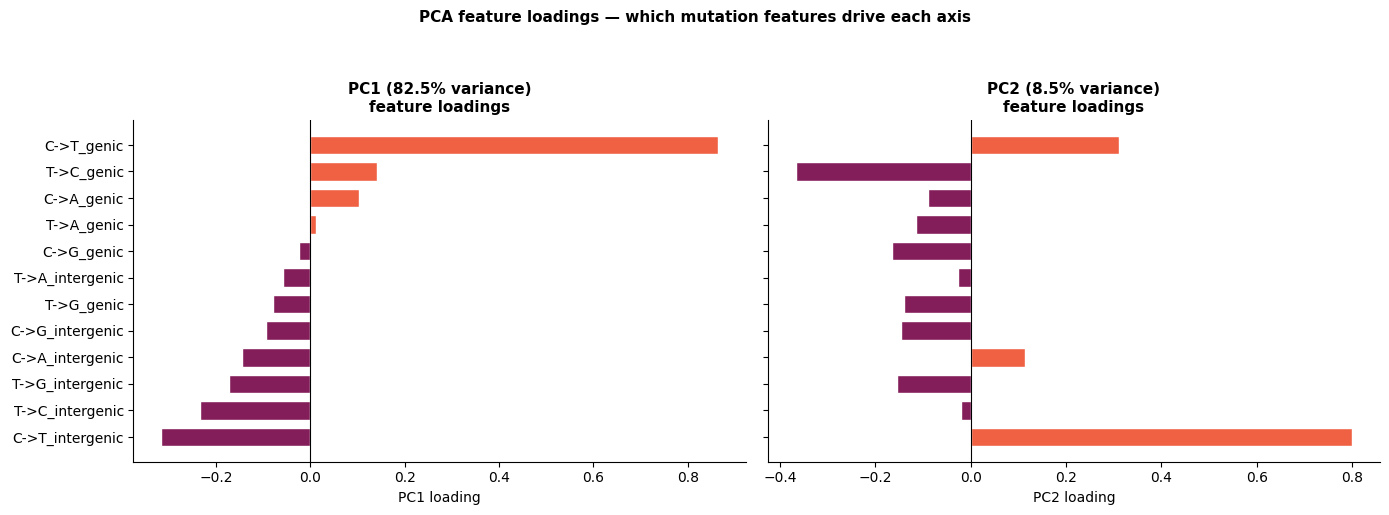

Saved pca_loadings.png
Saved pca_coordinates.csv


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# load files
file = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/mutation_summary_final_c.csv"
)
output_folder = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/charts/clustering"
)
os.makedirs(output_folder, exist_ok=True)
DPI = 300

# colour scheme, name formatting and gram group
ROCKET_FULL = sns.color_palette("rocket", 8)[1:-1]

def format_species_name(name):
    return f"$\\it{{{name[0].upper()}.\\ {name[1:]}}}$"

gram_markers = {
    "Gram-negative": "o",
    "Gram-positive": "s",
}

gram_groups = {
    "bpertussis":      "Gram-negative",
    "cjejuni":         "Gram-negative",
    "ecoli":           "Gram-negative",
    "hinfluenzae":     "Gram-negative",
    "kpneumoniae":     "Gram-negative",
    "nmeningitidis":   "Gram-negative",
    "paeruginosa":     "Gram-negative",
    "styphimurium":    "Gram-negative",
    "lmonocytogenesA": "Gram-positive",
    "mtuberculosis":   "Gram-positive",
    "sagalactiae":     "Gram-positive",
    "saureus":         "Gram-positive",
    "sepidermidis":    "Gram-positive",
    "spneumoniae":     "Gram-positive",
}

# make feature matrix from mutation rate and intergenic class
df = pd.read_csv(file)
df = df.groupby(["species", "mutation_class", "is_intergenic"], as_index=False).agg(
    {"no_mutations": "sum", "opportunities": "first"}
)
df["rate"] = df["no_mutations"] / df["opportunities"]
df["is_intergenic"] = df["is_intergenic"].astype(str).str.strip().str.lower().map(
    {"true": True, "false": False}
)
df["feature"] = df["mutation_class"] + "_" + df["is_intergenic"].map(
    {True: "intergenic", False: "genic"}
)

pivot = df.pivot_table(
    index="species", columns="feature", values="rate", aggfunc="mean"
).fillna(0)

X        = normalize(pivot.values, norm="l1")
species  = pivot.index.tolist()
features = pivot.columns.tolist()
n_sp     = len(species)

formatted_species = [format_species_name(sp) for sp in species]
fmt_to_sp         = dict(zip(formatted_species, species))


#####################
#hierarchical clustering using wards cosine linkage, calculate silhouette scores
linkage_matrix = linkage(X, method="ward")

print("\nSilhouette scores by number of clusters:")
sil_scores = {}
for k in range(2, min(7, n_sp)):
    cl            = fcluster(linkage_matrix, t=k, criterion="maxclust")
    sil           = silhouette_score(X, cl, metric="cosine")
    sil_scores[k] = sil
    print(f"  k={k}: silhouette = {sil:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nUsing k={best_k} (silhouette={sil_scores[best_k]:.4f})")

clusters  = fcluster(linkage_matrix, t=best_k, criterion="maxclust")
sil_score = silhouette_score(X, clusters, metric="cosine")
sil_samp  = silhouette_samples(X, clusters, metric="cosine")
#find info for dendrogram
cluster_ids     = sorted(set(clusters))
cluster_colours = {
    cl: ROCKET_FULL[int(i * (len(ROCKET_FULL) - 1) / max(len(cluster_ids) - 1, 1))]
    for i, cl in enumerate(cluster_ids)
}

sp_cluster_df = pd.DataFrame({
    "species":    species,
    "cluster":    clusters,
    "silhouette": sil_samp.round(4),
    "gram":       [gram_groups.get(sp, "unknown") for sp in species],
}).sort_values("cluster").reset_index(drop=True)

sp_to_colour = dict(zip(species, [cluster_colours[c] for c in clusters]))

cluster_handles = [
    mpatches.Patch(color=mcolors.to_hex(cluster_colours[cl]), label=f"Cluster {cl}")
    for cl in cluster_ids
]

#plot dendrogram with labels, legend, title
fig, ax = plt.subplots(figsize=(11, 5))

dend = dendrogram(linkage_matrix, labels=formatted_species, ax=ax,
                  leaf_rotation=45, color_threshold=0,
                  link_color_func=lambda k: "black")

for lbl in ax.get_xticklabels():
    fmt_name    = lbl.get_text()
    original_sp = fmt_to_sp.get(fmt_name, fmt_name)
    col         = mcolors.to_hex(sp_to_colour.get(original_sp, (0.3, 0.3, 0.3)))
    lbl.set_color(col)
    lbl.set_fontweight("bold")

ax.legend(handles=cluster_handles, fontsize=9, loc="upper right")
ax.set_title("Hierarchical clustering — 6-class mutation spectrum\n"
             "(labels coloured by cluster)", fontsize=12, fontweight="bold")
ax.set_xlabel("Species", fontsize=10)
ax.set_ylabel("Ward distance", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "hierarchical_clustering_6class.png"), dpi=DPI)
plt.show()
print("Saved hierarchical_clustering_6class.png")


# clustering method two: PCA, prints variance of PCs
pca      = PCA()
X_pca    = pca.fit_transform(X)
var_exp  = pca.explained_variance_ratio_
cum_var  = np.cumsum(var_exp)
loadings = pca.components_

print("\nVariance explained per PC:")
for i, (v, cv) in enumerate(zip(var_exp, cum_var)):
    print(f"  PC{i+1}: {v:.1%}  (cumulative: {cv:.1%})")
    if cv > 0.95:
        break

# plot species on scatter graph, gram marker have different shapes, 
fig, ax = plt.subplots(figsize=(10, 8))

for i, sp in enumerate(species):
    gram   = gram_groups.get(sp, "unknown")
    colour = mcolors.to_hex(cluster_colours[clusters[i]])
    marker = gram_markers.get(gram, "^")
    ax.scatter(X_pca[i, 0], X_pca[i, 1], s=140, color=colour,
               marker=marker, edgecolors="white", linewidths=0.8, zorder=3)
    ax.text(X_pca[i, 0] + 0.003, X_pca[i, 1] + 0.003,
            format_species_name(sp),
            fontsize=8, color=colour, fontweight="bold")

gram_leg = [
    plt.Line2D([0], [0], marker=gram_markers[g], color="w",
               markerfacecolor="grey", markersize=10, label=g)
    for g in gram_markers
]
ax.legend(handles=cluster_handles + gram_leg, fontsize=8,
          loc="best", framealpha=0.7)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1%} variance explained)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%} variance explained)", fontsize=10)
ax.set_title(
    f"PCA — 6-class mutation spectrum\n"
    f"Colour = cluster (k={best_k}, silhouette={sil_score:.3f}), "
    f"shape = Gram stain",
    fontsize=11, fontweight="bold"
)
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--", alpha=0.4)
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "pca_scatter.png"), dpi=DPI)
plt.show()
print("Saved pca_scatter.png")


# find loadings for PCs and plot on graph to see what drives clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, pc_idx, pc_name in zip(axes, [0, 1], ["PC1", "PC2"]):
    load    = loadings[pc_idx]
    load_df = pd.DataFrame({
        "feature": features, "loading": load
    }).sort_values("loading")
    colours_load = [
        mcolors.to_hex(ROCKET_FULL[4]) if v > 0 else mcolors.to_hex(ROCKET_FULL[1])
        for v in load_df["loading"]
    ]
    ax.barh(load_df["feature"], load_df["loading"],
            color=colours_load, edgecolor="white", height=0.7)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"{pc_name} loading", fontsize=10)
    ax.set_title(
        f"{pc_name} ({var_exp[pc_idx]:.1%} variance)\nfeature loadings",
        fontsize=11, fontweight="bold"
    )
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("PCA feature loadings — which mutation features drive each axis\n",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "pca_loadings.png"), dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved pca_loadings.png")


# save
pca_df = pd.DataFrame(X_pca[:, :5], index=species, columns=[f"PC{i+1}" for i in range(5)])
pca_df["cluster"] = clusters
pca_df["gram"]    = [gram_groups.get(s, "unknown") for s in species]
pca_df.to_csv(os.path.join(output_folder, "pca_coordinates.csv"))
print("Saved pca_coordinates.csv")
sp_cluster_df.to_csv(
    os.path.join(output_folder, "cluster_assignments_6class.csv"), index=False)